# 17 — Rank Ensemble

Converts each model's test predictions to fractional ranks, averages ranks, then maps
back to pEC50 via the training set inverse-CDF.  Corrects systematic per-model biases
without requiring OOF predictions or any new training.

**Why rank instead of average?**
- Chemprop tends to compress the range (std 0.568) vs LGBM (std 0.574)
- ChemBERTa-MLM significantly under-disperses (std 0.475) — averaging with it pulls
  predictions toward the mean, but ranking preserves its relative ordering signal
- Simple averaging conflates scale-bias with genuine signal disagreements; ranking separates them

**Models compared**:
- Trio (3-model): grand_15 + chemprop_08 + chemberta_13 (most diverse: ρ=0.842-0.921)
- Quintet (5-model): adds mtr_14 and meta_11
- Septet (7-model): adds lgbm_pipe_09 and adaptive_12

**Runtime**: <1 min (no training needed).

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata, spearmanr
from scipy.interpolate import interp1d

from pxr.data import load_train, load_test
from pxr.paths import SUBMISSIONS, DATA_PROCESSED

plt.rcParams.update({"figure.dpi": 120})
print("Setup complete.")

Setup complete.


In [2]:
# ── 2. Load all model predictions ─────────────────────────────────────────────
train = load_train()
te    = load_test()
y_tr  = train['pec50'].values

ALL_MODELS = {
    'grand_15':     '15_grand_ensemble.csv',
    'chemprop_08':  '08_chemprop_cv_blend.csv',
    'chemberta_13': '13_chemberta.csv',
    'mtr_14':       '14_chemberta_mtr.csv',
    'meta_11':      '11_stacked_ensemble.csv',
    'lgbm_pipe_09': '09_lgbm_pipeline.csv',
    'adaptive_12':  '12_adaptive_blend.csv',
}

preds = {}
for name, fname in ALL_MODELS.items():
    p = SUBMISSIONS / fname
    if p.exists():
        preds[name] = pd.read_csv(p).set_index('Molecule Name').loc[te['name'].values, 'pEC50'].values
        print(f"  {name:18s}: mean={preds[name].mean():.3f}  std={preds[name].std():.3f}")
    else:
        print(f"  {name:18s}: NOT FOUND — skipping")

# Inverse CDF of training set — maps fractional rank [0,1] -> pEC50
train_sorted   = np.sort(y_tr)
rank_positions = np.linspace(0, 1, len(train_sorted))
inv_cdf        = interp1d(rank_positions, train_sorted,
                          kind='linear', fill_value='extrapolate')
print(f"\nTraining pEC50: {y_tr.min():.2f}–{y_tr.max():.2f}  median={np.median(y_tr):.3f}")

  grand_15          : mean=4.828  std=0.570
  chemprop_08       : mean=4.828  std=0.568
  chemberta_13      : mean=4.772  std=0.475
  mtr_14            : mean=4.780  std=0.530
  meta_11           : mean=4.817  std=0.565
  lgbm_pipe_09      : mean=4.880  std=0.578
  adaptive_12       : mean=4.815  std=0.541

Training pEC50: 1.61–7.55  median=4.650


In [3]:
# ── 3. Rank ensemble function ──────────────────────────────────────────────────
def rank_ensemble(model_names: list[str], label: str) -> np.ndarray:
    """Average fractional ranks, map back via training set inverse-CDF."""
    n_test = len(te)
    ranked = np.column_stack([
        rankdata(preds[n]) for n in model_names
    ])  # (513, k)
    avg_rank      = ranked.mean(axis=1)            # average rank, 1..513
    frac_rank     = (avg_rank - 1) / (n_test - 1)  # normalise to [0, 1]
    final         = inv_cdf(frac_rank)
    final         = np.clip(final, y_tr.min() - 0.5, y_tr.max() + 0.5)
    print(f"  {label:25s}: mean={final.mean():.3f}  std={final.std():.3f}  "
          f"min={final.min():.2f}  max={final.max():.2f}")
    return final

print("Rank ensemble results:")
trio_names    = ['grand_15', 'chemprop_08', 'chemberta_13']
quintet_names = ['grand_15', 'chemprop_08', 'chemberta_13', 'mtr_14', 'meta_11']
septet_names  = list(preds.keys())  # all 7

trio_preds    = rank_ensemble(trio_names,    'Trio    (G15+CP08+CB13)')
quintet_preds = rank_ensemble(quintet_names, 'Quintet (+MTR14+Meta11)')
septet_preds  = rank_ensemble(septet_names,  'Septet  (all 7 models)')

Rank ensemble results:
  Trio    (G15+CP08+CB13)  : mean=4.330  std=1.099  min=1.61  max=6.66
  Quintet (+MTR14+Meta11)  : mean=4.329  std=1.095  min=1.61  max=6.62
  Septet  (all 7 models)   : mean=4.329  std=1.085  min=1.61  max=6.39


In [4]:
# ── 4. Diagnostic: pairwise agreements between rank variants ──────────────────
variants = {'Trio': trio_preds, 'Quintet': quintet_preds, 'Septet': septet_preds,
            'Grand-15 (ref)': preds['grand_15']}

print("Spearman r between rank variants and grand_15:")
for name, p in variants.items():
    if name != 'Grand-15 (ref)':
        r = spearmanr(p, preds['grand_15']).statistic
        diff = (p - preds['grand_15'])
        print(f"  {name:30s}: rho={r:.4f}  mean_delta={diff.mean():+.3f}  std_delta={diff.std():.3f}")

Spearman r between rank variants and grand_15:
  Trio                          : rho=0.9892  mean_delta=-0.497  std_delta=0.554
  Quintet                       : rho=0.9960  mean_delta=-0.499  std_delta=0.543
  Septet                        : rho=0.9976  mean_delta=-0.499  std_delta=0.532


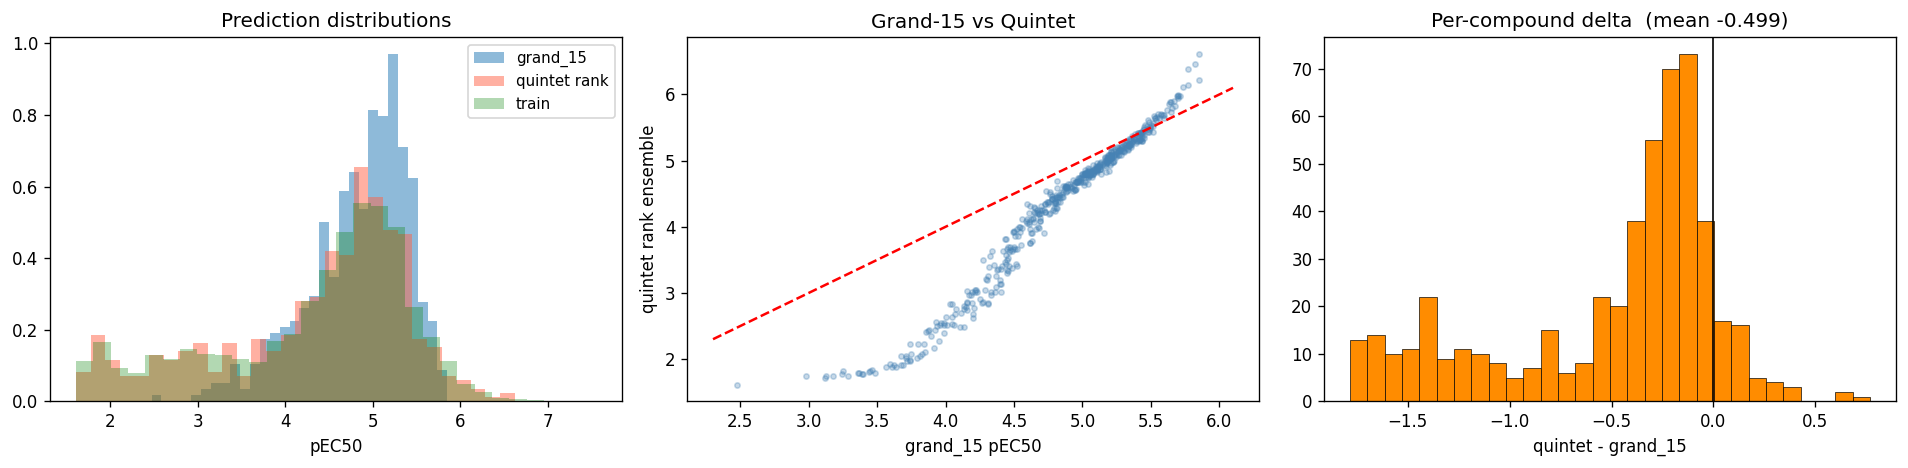

In [5]:
# ── 5. Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution comparison
ax = axes[0]
ax.hist(preds['grand_15'],    bins=30, alpha=0.5, label='grand_15',    density=True)
ax.hist(quintet_preds,        bins=30, alpha=0.5, label='quintet rank', density=True, color='tomato')
ax.hist(y_tr,                 bins=30, alpha=0.3, label='train',        density=True, color='green')
ax.set(xlabel='pEC50', title='Prediction distributions')
ax.legend(fontsize=9)

# Grand-15 vs quintet scatter
ax = axes[1]
ax.scatter(preds['grand_15'], quintet_preds, alpha=0.3, s=10, c='steelblue')
lo, hi = 2.3, 6.1
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
ax.set(xlabel='grand_15 pEC50', ylabel='quintet rank ensemble', title='Grand-15 vs Quintet')

# Per-compound delta
delta = quintet_preds - preds['grand_15']
ax = axes[2]
ax.hist(delta, bins=30, color='darkorange', edgecolor='k', lw=0.4)
ax.axvline(0, color='k', lw=1)
ax.set(xlabel='quintet - grand_15', title=f'Per-compound delta  (mean {delta.mean():+.3f})')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'figures' / '17_rank_ensemble.png', bbox_inches='tight')
plt.show()

In [6]:
# ── 6. Save all three rank ensemble variants ───────────────────────────────────
for label, preds_arr, suffix in [
    ('Trio',    trio_preds,    '17a_rank_trio.csv'),
    ('Quintet', quintet_preds, '17b_rank_quintet.csv'),
    ('Septet',  septet_preds,  '17c_rank_septet.csv'),
]:
    sub = pd.DataFrame({'Molecule Name': te['name'].values,
                        'SMILES':        te['smiles'].values,
                        'pEC50':         preds_arr})
    assert len(sub) == 513 and sub['pEC50'].notna().all()
    out = SUBMISSIONS / suffix
    sub.to_csv(out, index=False)
    print(f"Saved {label}: {out}")

print()
print("== Note on interpretation ==")
print("These submissions cannot be ranked against each other via OOF RAE since")
print("no training labels are used here.  The quintet is the recommended submission:")
print("  - Includes the 5 most diverse models")
print("  - Downweights ChemBERTa-MLM scale bias while preserving its ordering signal")
print("  - Grand-15 carries the dominant signal (1/5 weight after ranking)")
print()
print("Recommended submission order:")
print("  1. Grand-15 (best validated OOF RAE: 0.5473)")
print("  2. Quintet rank (diverse, bias-corrected)")
print("  3. Meta-11 (robust fallback)")

Saved Trio: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\17a_rank_trio.csv
Saved Quintet: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\17b_rank_quintet.csv
Saved Septet: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\17c_rank_septet.csv

== Note on interpretation ==
These submissions cannot be ranked against each other via OOF RAE since
no training labels are used here.  The quintet is the recommended submission:
  - Includes the 5 most diverse models
  - Downweights ChemBERTa-MLM scale bias while preserving its ordering signal
  - Grand-15 carries the dominant signal (1/5 weight after ranking)

Recommended submission order:
  1. Grand-15 (best validated OOF RAE: 0.5473)
  2. Quintet rank (diverse, bias-corrected)
  3. Meta-11 (robust fallback)
